# Entrega 5: análise e figuras do artigo

Produz as tabelas e as figuras que vão direto para a seção de resultados. Tudo em **Arial 12**, fundo branco, 300 dpi, no formato que o Word aceita sem retrabalho.

Cada figura é salva em `05_figuras` e cada tabela em `05_tabelas`, com numeração sequencial e **legenda sugerida impressa na saída**, no padrão do artigo (`Figura N. Título` seguido de `Fonte: Resultados originais da pesquisa`). É só copiar.

## O que entra e o que fica de fora

Nenhum modelo é estimado aqui. Isto é caracterização, comparação de grupos e avaliação dos escores clássicos como linha de base. A modelagem com os três algoritmos é a entrega seguinte.

| Camada | Papel no artigo | O que sai daqui |
|---|---|---|
| A. CVM | Estudo principal de insolvência | Caracterização, comparação entre insolventes e saudáveis, testes de diferença, estudo de evento e desempenho de Kanitz e Altman |
| C. Receita Federal | Estudo de mortalidade em Minas | Perfil da coorte, mortalidade por setor e porte, curva de sobrevivência |
| B. BACEN | Caracterização do sistema financeiro | Evolução do Basileia e da rentabilidade, recorte mineiro |

A camada B entra como descrição, e não como previsão, por uma razão empírica que vale registrar no texto: a relação de regimes especiais do Banco Central é um **cadastro corrente**, não um histórico. Ela traz apenas as instituições ainda em liquidação, quase todas decretadas em 2025 e 2026, fora da janela do painel. Não é limitação do método, é característica da fonte.

## 1. Configuração visual

In [1]:
!pip install -q pandas numpy matplotlib scipy scikit-learn openpyxl

In [2]:
import json
import warnings
import unicodedata
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

A fonte é fixada em Arial 12. Se o sistema não tiver Arial instalada, a célula avisa e cai para a fonte padrão, e aí vale instalar antes de gerar as versões finais das figuras, porque a norma do trabalho pede Arial.

In [4]:
FONTE = "Arial"
disponiveis = {f.name for f in mpl.font_manager.fontManager.ttflist}
if FONTE not in disponiveis:
    print(f"ATENCAO: {FONTE} nao encontrada. Figuras sairao com a fonte padrao.")
    print("Alternativas presentes:", sorted(x for x in disponiveis if "arial" in x.lower() or "helvet" in x.lower())[:5])
    FONTE = mpl.rcParams["font.family"][0]
else:
    print(f"{FONTE} disponivel")

mpl.rcParams.update({
    "font.family": FONTE,
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#52514e",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
    "figure.autolayout": False,
})

AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
CINZA, CINZA_CLARO = "#52514e", "#c3c2b7"
DIV_NEG, DIV_NEUTRO, DIV_POS = "#2a78d6", "#f0efec", "#d03b3b"
print("paleta definida")

Arial disponivel
paleta definida


In [5]:
RAIZ = Path(r"G:\Meu Drive\TCC\Damaris Rebeca")
DIR_MODELAGEM = RAIZ / "04_modelagem"
DIR_FIG = RAIZ / "05_figuras"
DIR_TAB = RAIZ / "05_tabelas"
for d in (DIR_FIG, DIR_TAB):
    d.mkdir(parents=True, exist_ok=True)

FIGURAS, TABELAS = [], []

def salvar_figura(fig, numero, titulo, nota=""):
    nome = f"fig{numero:02d}"
    caminho = DIR_FIG / f"{nome}.png"
    fig.savefig(caminho, bbox_inches="tight", facecolor="white")
    FIGURAS.append({"numero": numero, "arquivo": caminho.name, "titulo": titulo})
    print(f"\n[salvo] {caminho.name}")
    print("-" * 74)
    print(f"Figura {numero}. {titulo}")
    if nota:
        print(nota)
    print("Fonte: Resultados originais da pesquisa")
    print("-" * 74)
    return caminho

def salvar_tabela(df, numero, titulo, indice=False):
    nome = f"tab{numero:02d}"
    caminho = DIR_TAB / f"{nome}.csv"
    df.to_csv(caminho, index=indice, encoding="utf-8-sig", sep=";", decimal=",")
    TABELAS.append({"numero": numero, "arquivo": caminho.name, "titulo": titulo, "dados": df})
    print(f"\n[salvo] {caminho.name}")
    print("-" * 74)
    print(f"Tabela {numero}. {titulo}")
    print("Fonte: Resultados originais da pesquisa")
    print("-" * 74)
    return caminho

def milhares(x, pos=None):
    return f"{x:,.0f}".replace(",", ".")

def rotular_barras(ax, barras, formato="{:,.0f}", desloc=0.01, cor="#0b0b0b"):
    limite = ax.get_ylim()[1]
    for b in barras:
        altura = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, altura + desloc * limite,
                formato.format(altura).replace(",", "."), ha="center", va="bottom",
                fontsize=11, color=cor)

def normalizar(s):
    s = unicodedata.normalize("NFKD", str(s) if pd.notna(s) else "")
    return " ".join(s.encode("ascii", "ignore").decode("ascii").upper().split())

print("saida de figuras:", DIR_FIG)
print("saida de tabelas:", DIR_TAB)

saida de figuras: G:\Meu Drive\TCC\Damaris Rebeca\05_figuras
saida de tabelas: G:\Meu Drive\TCC\Damaris Rebeca\05_tabelas


## 2. Leitura das camadas

In [7]:
def ler(nome, pasta=DIR_MODELAGEM):
    caminho = pasta / f"{nome}.parquet"
    if not caminho.exists():
        print(f"AUSENTE: {caminho.name}")
        return None
    df = pd.read_parquet(caminho)
    print(f"{nome:<32}{len(df):>10,} linhas x {df.shape[1]:>3} colunas")
    return df

A = ler("camada_a_wrangled")
B = ler("camada_b_recuperada")
Cc = ler("camada_c_wrangled")

A_elegivel = A[A["descartar_pos_evento"] == 0].copy() if A is not None else None

IND_A = [c for c in A.columns
         if A[c].dtype.kind == "f" and not c.startswith("y_")
         and c not in ("ativo_total", "receita_liquida", "patrimonio_liquido",
                       "lucro_liquido", "log_ativo")] if A is not None else []
print(f"\n{len(IND_A)} indicadores na camada A:")
print(", ".join(IND_A))

camada_a_wrangled                    8,611 linhas x  47 colunas
camada_b_recuperada                 16,552 linhas x  40 colunas
camada_c_wrangled                1,415,279 linhas x  36 colunas

24 indicadores na camada A:
liquidez_corrente, liquidez_imediata, liquidez_geral, endividamento_geral, endividamento_financeiro, composicao_endividamento, alavancagem, pl_sobre_exigivel, imobilizacao_recursos, roe, margem_liquida, margem_bruta, margem_operacional, ebit_sobre_ativo, lucros_acumulados_ativo, retorno_antes_tributos, giro_ativo, ccl_sobre_ativo, capital_giro_receita, cobertura_juros, despesa_financeira_receita, crescimento_receita, crescimento_ativo, altman_z2_emergentes


---
# 3. Camada A: companhias abertas

## 3.1 Caracterização da amostra

In [9]:
eventos = (A[A["y_rj"] == 1][["CNPJ_CIA", "DENOM_CIA", "ANO", "uf", "setor"]]
             .assign(ano_evento=lambda d: d["ANO"] + 1)
             .sort_values("ano_evento"))

resumo = pd.DataFrame([
    ["Observações empresa-exercício", f"{len(A):,}".replace(",", ".")],
    ["Observações elegíveis para modelagem", f"{len(A_elegivel):,}".replace(",", ".")],
    ["Companhias abertas distintas", f"{A['CNPJ_CIA'].nunique():,}".replace(",", ".")],
    ["Período coberto", f"{int(A['ANO'].min())} a {int(A['ANO'].max())}"],
    ["Eventos de recuperação judicial ou falência", f"{len(eventos)}"],
    ["Taxa de eventos", f"{A_elegivel['y_rj'].mean():.2%}".replace(".", ",")],
    ["Observações em dificuldade financeira severa", f"{int(A_elegivel['y_distress'].sum()):,}".replace(",", ".")],
    ["Taxa de dificuldade financeira", f"{A_elegivel['y_distress'].mean():.2%}".replace(".", ",")],
    ["Indicadores financeiros calculados", f"{len(IND_A)}"],
    ["Companhias com sede em Minas Gerais", f"{A[A['uf'] == 'MG']['CNPJ_CIA'].nunique()}"],
], columns=["Característica", "Valor"])

salvar_tabela(resumo, 1, "Caracterização da amostra de companhias abertas")
print(resumo.to_string(index=False))


[salvo] tab01.csv
--------------------------------------------------------------------------
Tabela 1. Caracterização da amostra de companhias abertas
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                              Característica       Valor
               Observações empresa-exercício       8.611
        Observações elegíveis para modelagem       8.453
                Companhias abertas distintas         980
                             Período coberto 2011 a 2025
 Eventos de recuperação judicial ou falência          48
                             Taxa de eventos       0,57%
Observações em dificuldade financeira severa       2.005
              Taxa de dificuldade financeira      23,72%
          Indicadores financeiros calculados          24
         Companhias com sede em Minas Gerais          77



[salvo] fig01.png
--------------------------------------------------------------------------
Figura 1. Distribuição anual dos eventos de recuperação judicial e falência entre companhias abertas, 2012 a 2026
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


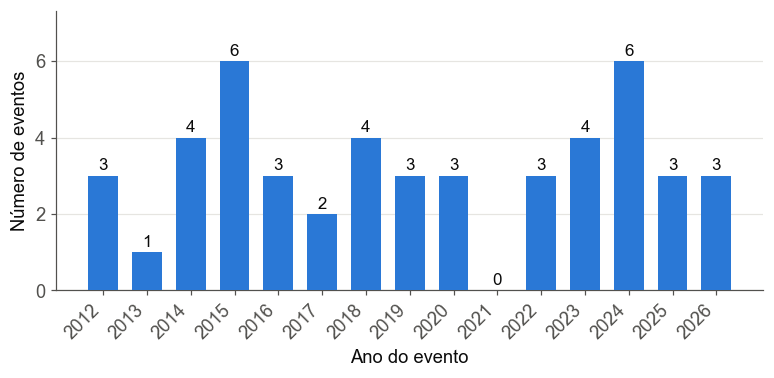

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
contagem = eventos["ano_evento"].value_counts().sort_index()
anos = list(range(int(contagem.index.min()), int(contagem.index.max()) + 1))
valores = [int(contagem.get(a, 0)) for a in anos]

barras = ax.bar(anos, valores, color=AZUL, width=0.68, zorder=3)
ax.set_ylabel("Número de eventos")
ax.set_xlabel("Ano do evento")
ax.set_xticks(anos)
ax.set_xticklabels(anos, rotation=45, ha="right")
ax.set_ylim(0, max(valores) * 1.22)
ax.yaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
rotular_barras(ax, barras)
fig.tight_layout()

salvar_figura(fig, 1, "Distribuição anual dos eventos de recuperação judicial e falência entre companhias abertas, 2012 a 2026")
plt.show()


[salvo] fig02.png
--------------------------------------------------------------------------
Figura 2. Distribuição das companhias abertas por unidade da federação da sede, dez maiores
Nota: Minas Gerais destacado em laranja.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


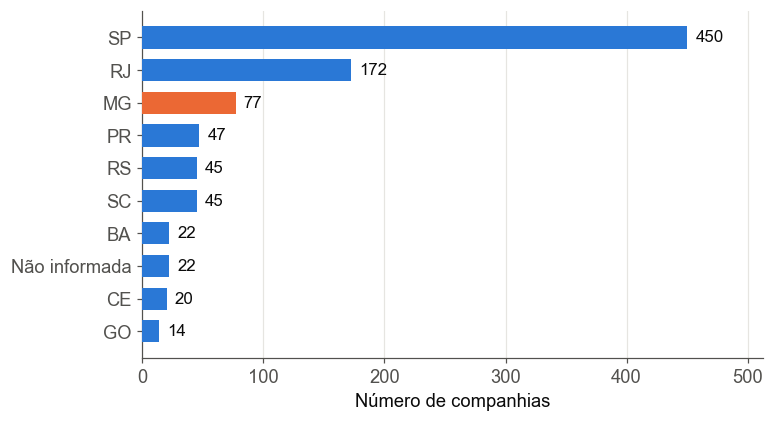

In [11]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
por_uf = (A.drop_duplicates(subset=["CNPJ_CIA"])["uf"].replace("", "Não informada")
            .value_counts().head(10).sort_values())
cores = [LARANJA if uf == "MG" else AZUL for uf in por_uf.index]

barras = ax.barh(por_uf.index, por_uf.values, color=cores, height=0.68, zorder=3)
ax.set_xlabel("Número de companhias")
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.set_xlim(0, por_uf.max() * 1.14)
for b, v in zip(barras, por_uf.values):
    ax.text(v + por_uf.max() * 0.015, b.get_y() + b.get_height() / 2,
            f"{v:,}".replace(",", "."), va="center", fontsize=11)
fig.tight_layout()

salvar_figura(fig, 2, "Distribuição das companhias abertas por unidade da federação da sede, dez maiores",
              nota="Nota: Minas Gerais destacado em laranja.")
plt.show()

## 3.2 Estatísticas descritivas

In [13]:
desc = A_elegivel[IND_A].describe().T
desc["p1"] = A_elegivel[IND_A].quantile(0.01)
desc["p99"] = A_elegivel[IND_A].quantile(0.99)
desc = desc[["count", "mean", "std", "p1", "25%", "50%", "75%", "p99"]]
desc.columns = ["N", "Média", "Desvio padrão", "P1", "Q1", "Mediana", "Q3", "P99"]
desc.index.name = "Indicador"
desc = desc.round(4)

salvar_tabela(desc, 2, "Estatísticas descritivas dos indicadores financeiros", indice=True)
print(desc.to_string())


[salvo] tab02.csv
--------------------------------------------------------------------------
Tabela 2. Estatísticas descritivas dos indicadores financeiros
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                                 N   Média  Desvio padrão        P1      Q1  Mediana      Q3        P99
Indicador                                                                                              
liquidez_corrente           8356.0  4.1065        22.4372    0.0099  0.8437   1.3799  2.2670    59.6737
liquidez_imediata           8356.0  2.5168        15.8261    0.0000  0.1563   0.4531  0.9984    48.6000
liquidez_geral              8376.0  3.0868        22.0185    0.0103  0.4148   0.7915  1.2648    47.8881
endividamento_geral         8453.0  1.3102         4.6105    0.0005  0.4539   0.6409  0.8021    25.5000
endividamento_financeiro    8453.0  0.3869         0.7438    0.0000  0.1018   0.3023  0.4738     3.4940


## 3.3 Comparação entre grupos

Compara as companhias no exercício que antecede o evento contra as demais. O teste é de **Mann-Whitney**, não o teste t, porque indicadores financeiros têm distribuição fortemente assimétrica e caudas pesadas mesmo após winsorização. O tamanho de efeito é o **delta de Cliff**, que mede a probabilidade de um valor sorteado de um grupo superar o do outro e não depende de normalidade.

In [15]:
def cliff_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    if len(x) == 0 or len(y) == 0:
        return np.nan
    maior = sum((x[:, None] > y[None, :]).sum(axis=1))
    menor = sum((x[:, None] < y[None, :]).sum(axis=1))
    return (maior - menor) / (len(x) * len(y))

def classificar_efeito(d):
    a = abs(d)
    if np.isnan(a):
        return ""
    if a < 0.147:
        return "desprezível"
    if a < 0.33:
        return "pequeno"
    if a < 0.474:
        return "médio"
    return "grande"

linhas = []
for ind in IND_A:
    g1 = A_elegivel.loc[A_elegivel["y_rj"] == 1, ind].dropna()
    g0 = A_elegivel.loc[A_elegivel["y_rj"] == 0, ind].dropna()
    if len(g1) < 5 or len(g0) < 5:
        continue
    amostra0 = g0.sample(min(len(g0), 3000), random_state=42)
    try:
        _, p = mannwhitneyu(g1, g0, alternative="two-sided")
    except Exception:
        p = np.nan
    d = cliff_delta(g1.values, amostra0.values)
    linhas.append({"Indicador": ind, "N insolventes": len(g1), "N saudáveis": len(g0),
                   "Mediana insolventes": round(g1.median(), 4),
                   "Mediana saudáveis": round(g0.median(), 4),
                   "p-valor": p, "Delta de Cliff": round(d, 3),
                   "Efeito": classificar_efeito(d)})

testes = pd.DataFrame(linhas).sort_values("Delta de Cliff")
testes["p-valor"] = testes["p-valor"].map(lambda v: "<0,001" if v < 0.001 else f"{v:.3f}".replace(".", ","))

salvar_tabela(testes, 3, "Comparação dos indicadores financeiros entre companhias insolventes e saudáveis")
print(testes.to_string(index=False))


[salvo] tab03.csv
--------------------------------------------------------------------------
Tabela 3. Comparação dos indicadores financeiros entre companhias insolventes e saudáveis
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                 Indicador  N insolventes  N saudáveis  Mediana insolventes  Mediana saudáveis p-valor  Delta de Cliff      Efeito
            margem_liquida             37         7462              -0.6760             0.0553  <0,001          -0.779      grande
        margem_operacional             37         7482              -0.1441             0.1309  <0,001          -0.647      grande
           cobertura_juros             44         7785              -0.4376             1.1756  <0,001          -0.634      grande
      capital_giro_receita             37         7482              -0.6187             0.1353  <0,001          -0.627      grande
         crescimento_ativo             45     


[salvo] fig03.png
--------------------------------------------------------------------------
Figura 3. Distribuição dos seis indicadores de maior poder discriminante entre companhias saudáveis e insolventes
Nota: valores extremos omitidos para legibilidade. Os indicadores foram winsorizados nos percentis 1 e 99 por exercício.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


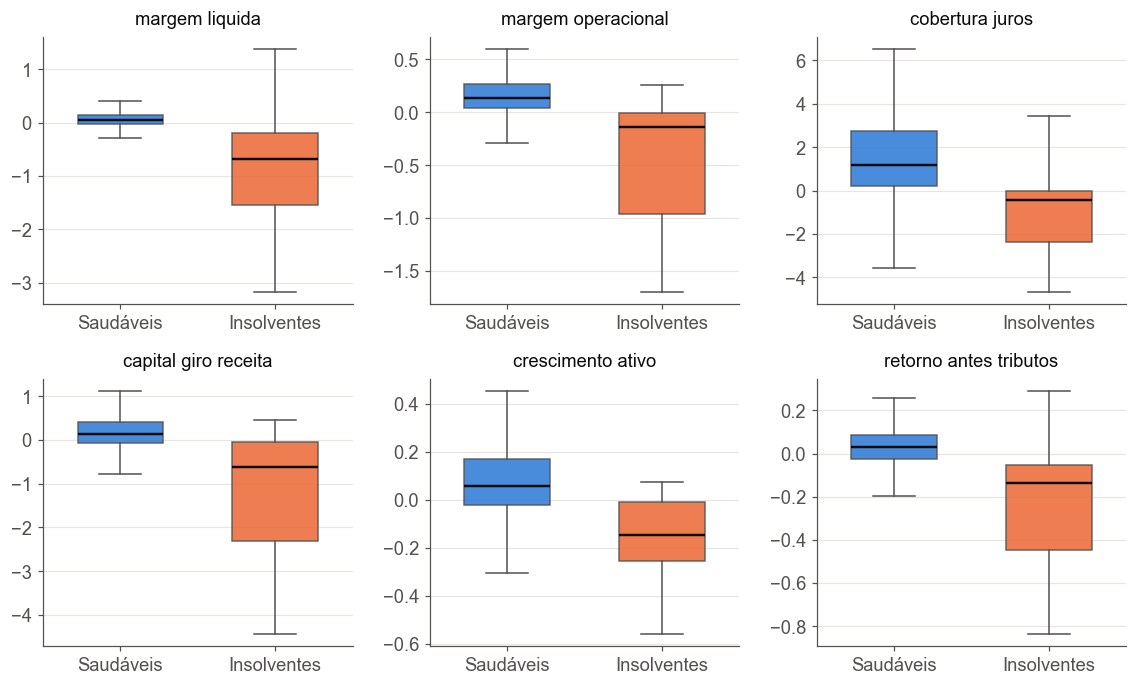

In [16]:
relevantes = (pd.DataFrame(linhas).assign(abs_d=lambda d: d["Delta de Cliff"].abs())
                .sort_values("abs_d", ascending=False)["Indicador"].head(6).tolist())

fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.4))
for ax, ind in zip(axes.ravel(), relevantes):
    dados = [A_elegivel.loc[A_elegivel["y_rj"] == 0, ind].dropna(),
             A_elegivel.loc[A_elegivel["y_rj"] == 1, ind].dropna()]
    bp = ax.boxplot(dados, patch_artist=True, widths=0.55, showfliers=False,
                    medianprops=dict(color="#0b0b0b", linewidth=1.6),
                    whiskerprops=dict(color=CINZA), capprops=dict(color=CINZA),
                    boxprops=dict(edgecolor=CINZA, linewidth=1.0))
    for caixa, cor in zip(bp["boxes"], [AZUL, LARANJA]):
        caixa.set_facecolor(cor)
        caixa.set_alpha(0.85)
    ax.set_xticklabels(["Saudáveis", "Insolventes"])
    ax.set_title(ind.replace("_", " "), pad=8)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
fig.tight_layout()

salvar_figura(fig, 3, "Distribuição dos seis indicadores de maior poder discriminante entre companhias saudáveis e insolventes",
              nota="Nota: valores extremos omitidos para legibilidade. Os indicadores foram winsorizados nos percentis 1 e 99 por exercício.")
plt.show()

## 3.4 Estudo de evento

Acompanha a mediana dos indicadores nos três exercícios que antecedem a insolvência, contra a mediana das companhias saudáveis no mesmo período. É a figura que mostra **quando** o sinal contábil aparece, e costuma ser a mais citada em bancas porque responde à pergunta prática de com quanta antecedência dá para agir.


[salvo] fig04.png
--------------------------------------------------------------------------
Figura 4. Trajetória mediana dos indicadores nos exercícios que antecedem a insolvência
Nota: o eixo horizontal indica o número de exercícios antes do evento.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


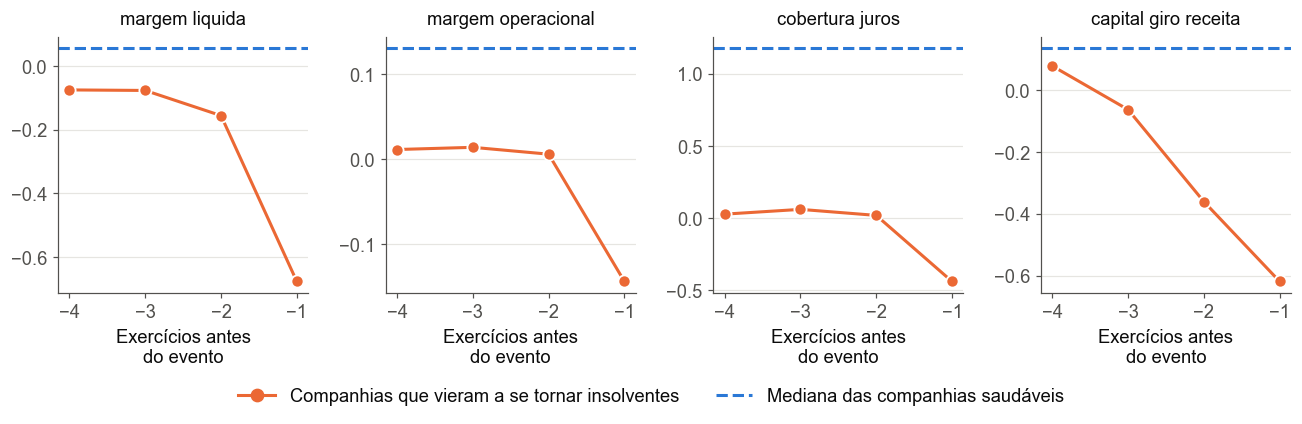

In [18]:
mapa_evento = dict(zip(eventos["CNPJ_CIA"], eventos["ano_evento"]))
painel_evento = A[A["CNPJ_CIA"].isin(mapa_evento)].copy()
painel_evento["ano_evento"] = painel_evento["CNPJ_CIA"].map(mapa_evento)
painel_evento["t"] = painel_evento["ANO"] - painel_evento["ano_evento"]
janela = painel_evento[painel_evento["t"].between(-4, -1)]

escolhidos = [c for c in ["roa", "liquidez_corrente", "endividamento_geral", "cobertura_juros"]
              if c in IND_A][:4]
if len(escolhidos) < 4:
    escolhidos = relevantes[:4]

fig, axes = plt.subplots(1, len(escolhidos), figsize=(3.0 * len(escolhidos), 3.6), sharex=True)
axes = np.atleast_1d(axes)
for ax, ind in zip(axes, escolhidos):
    serie = janela.groupby("t")[ind].median()
    referencia = A_elegivel.loc[A_elegivel["y_rj"] == 0, ind].median()
    ax.axhline(referencia, color=AZUL, linewidth=2, linestyle="--", zorder=2)
    ax.plot(serie.index, serie.values, color=LARANJA, linewidth=2, marker="o",
            markersize=8, markeredgecolor="white", markeredgewidth=1.2, zorder=3)
    ax.set_title(ind.replace("_", " "), pad=8)
    ax.set_xticks([-4, -3, -2, -1])
    ax.set_xlabel("Exercícios antes\ndo evento")
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)

linhas_legenda = [plt.Line2D([], [], color=LARANJA, marker="o", linewidth=2, markersize=8),
                  plt.Line2D([], [], color=AZUL, linewidth=2, linestyle="--")]
fig.legend(linhas_legenda, ["Companhias que vieram a se tornar insolventes", "Mediana das companhias saudáveis"],
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.09))
fig.tight_layout()

salvar_figura(fig, 4, "Trajetória mediana dos indicadores nos exercícios que antecedem a insolvência",
              nota="Nota: o eixo horizontal indica o número de exercícios antes do evento.")
plt.show()

## 3.5 Correlação entre indicadores


[salvo] fig05.png
--------------------------------------------------------------------------
Figura 5. Matriz de correlação de Spearman entre os indicadores financeiros
Nota: indicadores com correlação absoluta acima de 0,95 já haviam sido removidos no tratamento.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


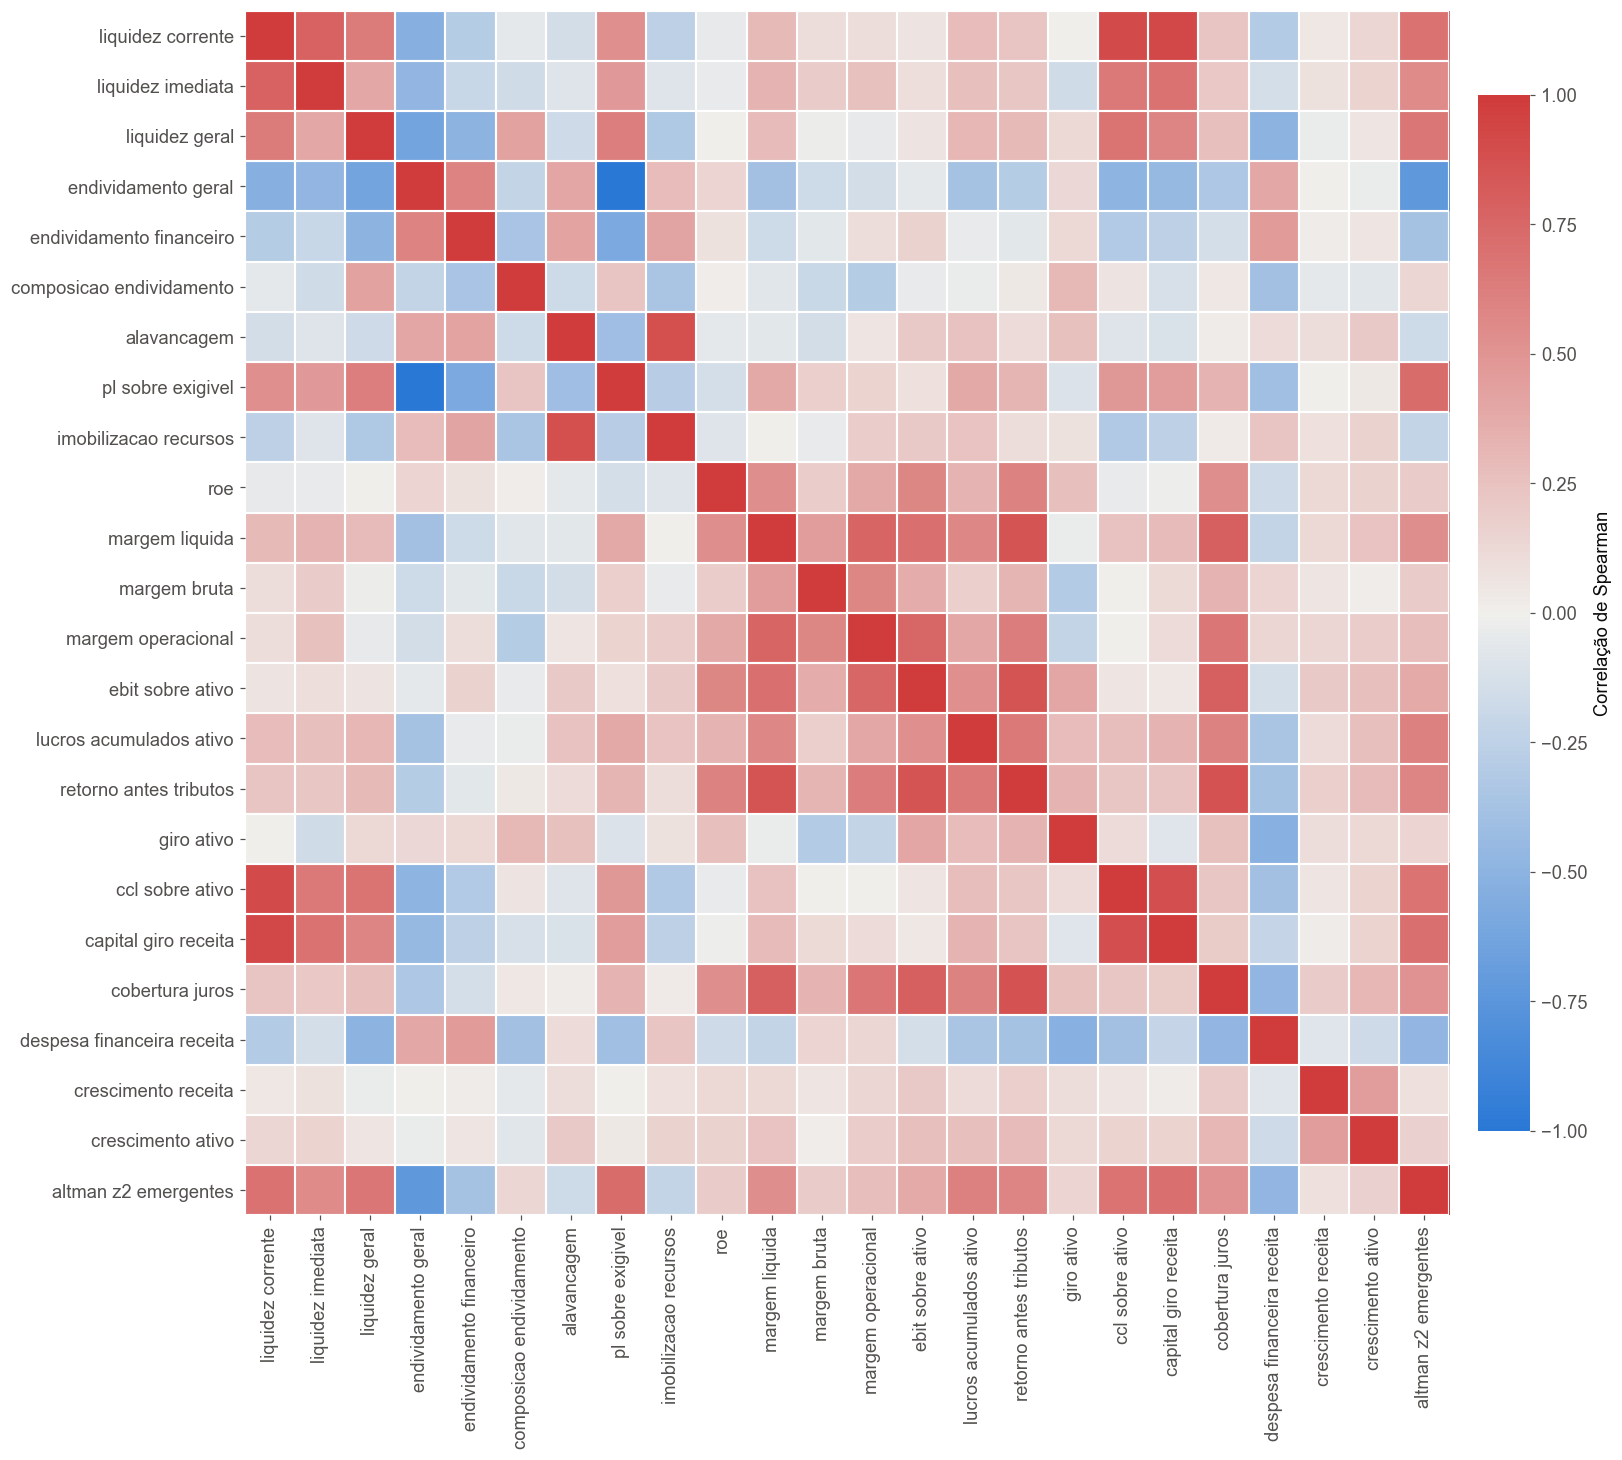

In [20]:
corr = A_elegivel[IND_A].corr(method="spearman")
n = len(IND_A)
fig, ax = plt.subplots(figsize=(0.52 * n + 3.2, 0.52 * n + 2.4))
cmap = mpl.colors.LinearSegmentedColormap.from_list("div", [DIV_NEG, DIV_NEUTRO, DIV_POS])
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)

rotulos = [c.replace("_", " ") for c in IND_A]
ax.set_xticks(range(n)); ax.set_xticklabels(rotulos, rotation=90)
ax.set_yticks(range(n)); ax.set_yticklabels(rotulos)
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.4)
ax.tick_params(which="minor", length=0)
for lado in ("top", "right", "bottom", "left"):
    ax.spines[lado].set_visible(False)

cb = fig.colorbar(im, ax=ax, shrink=0.72, pad=0.02)
cb.set_label("Correlação de Spearman")
cb.outline.set_visible(False)
fig.tight_layout()

salvar_figura(fig, 5, "Matriz de correlação de Spearman entre os indicadores financeiros",
              nota="Nota: indicadores com correlação absoluta acima de 0,95 já haviam sido removidos no tratamento.")
plt.show()

## 3.6 Linha de base: Kanitz e Altman

Esta é a seção que sustenta a contribuição original do trabalho. Antes de estimar qualquer modelo de aprendizado de máquina, é preciso saber o quanto os escores clássicos já entregam sozinhos. Sem esse número, dizer que o machine learning teve bom desempenho não significa nada, porque não há contra o quê comparar.

O Termômetro de Kanitz (1978) e o Z'' de Altman para mercados emergentes são avaliados como classificadores diretos, pela área sob a curva ROC. Ambos são orientados de modo que valores **baixos** indicam risco, então o escore é invertido para que a curva seja lida na direção usual.

In [22]:
escores = [c for c in ["kanitz_fi", "altman_z2_emergentes"] if c in A_elegivel.columns]
nomes = {"kanitz_fi": "Termômetro de Kanitz", "altman_z2_emergentes": "Z'' de Altman"}
cores_escore = {"kanitz_fi": AZUL, "altman_z2_emergentes": LARANJA}

resultados, curvas = [], {}
for alvo, rotulo_alvo in [("y_rj", "Recuperação judicial ou falência"),
                          ("y_distress", "Dificuldade financeira severa")]:
    for esc in escores:
        d = A_elegivel[[esc, alvo]].dropna()
        if d[alvo].sum() < 5:
            continue
        y = d[alvo].values
        pontuacao = -d[esc].values
        auc = roc_auc_score(y, pontuacao)
        fpr, tpr, limiares = roc_curve(y, pontuacao)
        j = np.argmax(tpr - fpr)
        resultados.append({
            "Escore": nomes[esc], "Desfecho": rotulo_alvo, "N": len(d),
            "Positivos": int(y.sum()), "AUC-ROC": round(auc, 3),
            "Sensibilidade no ponto de Youden": round(tpr[j], 3),
            "Especificidade no ponto de Youden": round(1 - fpr[j], 3),
            "Limiar do escore": round(-limiares[j], 4),
        })
        if alvo == "y_rj":
            curvas[esc] = (fpr, tpr, auc)

baseline = pd.DataFrame(resultados)
salvar_tabela(baseline, 4, "Desempenho dos escores clássicos de insolvência como classificadores")
print(baseline.to_string(index=False))


[salvo] tab04.csv
--------------------------------------------------------------------------
Tabela 4. Desempenho dos escores clássicos de insolvência como classificadores
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
       Escore                         Desfecho    N  Positivos  AUC-ROC  Sensibilidade no ponto de Youden  Especificidade no ponto de Youden  Limiar do escore
Z'' de Altman Recuperação judicial ou falência 8354         48    0.705                             0.729                              0.814             2.599
Z'' de Altman    Dificuldade financeira severa 8354       1998    0.854                             0.759                              0.874             3.735



[salvo] fig06.png
--------------------------------------------------------------------------
Figura 6. Curva ROC dos escores clássicos na previsão de recuperação judicial e falência
Nota: a linha tracejada representa a classificação aleatória.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


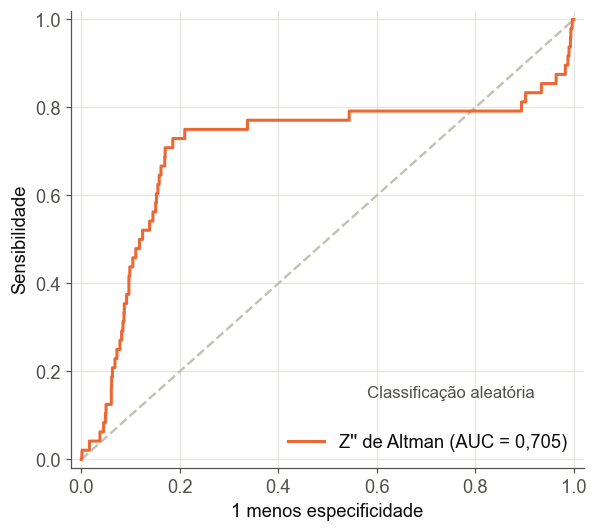

In [23]:
fig, ax = plt.subplots(figsize=(5.6, 5.0))
ax.plot([0, 1], [0, 1], color=CINZA_CLARO, linewidth=1.6, linestyle="--", zorder=2)
for esc, (fpr, tpr, auc) in curvas.items():
    ax.plot(fpr, tpr, color=cores_escore[esc], linewidth=2, zorder=3,
            label=f"{nomes[esc]} (AUC = {auc:.3f})".replace(".", ","))
ax.set_xlabel("1 menos especificidade")
ax.set_ylabel("Sensibilidade")
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
ax.grid(True); ax.set_axisbelow(True)
ax.legend(loc="lower right")
ax.text(0.58, 0.14, "Classificação aleatória", color=CINZA, fontsize=11, rotation=0)
fig.tight_layout()

salvar_figura(fig, 6, "Curva ROC dos escores clássicos na previsão de recuperação judicial e falência",
              nota="Nota: a linha tracejada representa a classificação aleatória.")
plt.show()


[salvo] tab05.csv
--------------------------------------------------------------------------
Tabela 5. Distribuição dos desfechos por faixa do Termômetro de Kanitz
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                               Saudáveis (%)  Insolventes (%)  Observações
Faixa do Termômetro de Kanitz                                             
insolvente                            98.421            1.579          190
penumbra                              98.667            1.333          450
solvente                              99.493            0.507         7698

[salvo] fig07.png
--------------------------------------------------------------------------
Figura 7. Taxa de insolvência observada por faixa de classificação do Termômetro de Kanitz
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


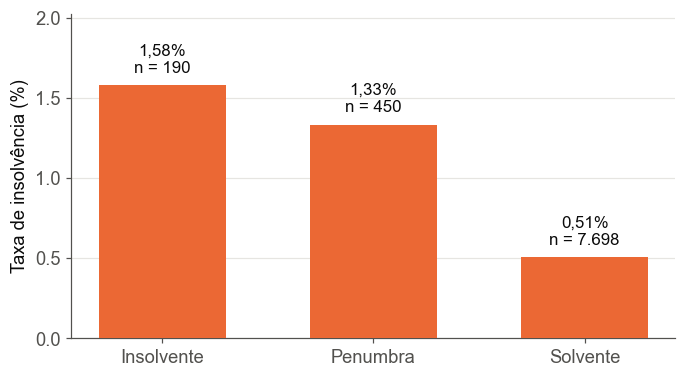

In [24]:
if "kanitz_faixa" in A_elegivel.columns:
    tab = pd.crosstab(A_elegivel["kanitz_faixa"], A_elegivel["y_rj"], normalize="index") * 100
    tab.columns = ["Saudáveis (%)", "Insolventes (%)"]
    contagem = A_elegivel["kanitz_faixa"].value_counts()
    tab["Observações"] = contagem
    ordem = [x for x in ["insolvente", "penumbra", "solvente"] if x in tab.index]
    tab = tab.loc[ordem].round(3)
    tab.index.name = "Faixa do Termômetro de Kanitz"

    salvar_tabela(tab, 5, "Distribuição dos desfechos por faixa do Termômetro de Kanitz", indice=True)
    print(tab.to_string())

    fig, ax = plt.subplots(figsize=(6.4, 3.6))
    barras = ax.bar(range(len(ordem)), tab["Insolventes (%)"].values, color=LARANJA,
                    width=0.6, zorder=3)
    ax.set_xticks(range(len(ordem)))
    ax.set_xticklabels([x.capitalize() for x in ordem])
    ax.set_ylabel("Taxa de insolvência (%)")
    ax.set_ylim(0, max(tab["Insolventes (%)"].max() * 1.28, 0.5))
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    for b, v, n in zip(barras, tab["Insolventes (%)"].values, tab["Observações"].values):
        ax.text(b.get_x() + b.get_width() / 2, v + ax.get_ylim()[1] * 0.03,
                f"{v:.2f}%".replace(".", ",") + f"\nn = {n:,}".replace(",", "."),
                ha="center", va="bottom", fontsize=11)
    fig.tight_layout()

    salvar_figura(fig, 7, "Taxa de insolvência observada por faixa de classificação do Termômetro de Kanitz")
    plt.show()

---
# 4. Camada C: mortalidade empresarial em Minas Gerais

In [26]:
perfil_c = pd.DataFrame([
    ["Empresas na coorte", f"{len(Cc):,}".replace(",", ".")],
    ["Anos de abertura", f"{int(Cc['ano_abertura'].min())} a {int(Cc['ano_abertura'].max())}"],
    ["Municípios representados", f"{Cc['municipio_nome'].nunique():,}".replace(",", ".")],
    ["Seções CNAE representadas", f"{Cc['cnae_secao'].nunique()}"],
    ["Taxa de mortalidade em cinco anos", f"{Cc['y_mortalidade'].mean():.2%}".replace(".", ",")],
    ["Encerramentos voluntários", f"{Cc['y_encerramento_voluntario'].mean():.2%}".replace(".", ",")],
    ["Baixas involuntárias", f"{Cc['y_baixa_involuntaria'].mean():.2%}".replace(".", ",")],
    ["Insolvência formal", f"{Cc['y_insolvencia_formal'].mean():.3%}".replace(".", ",")],
    ["Optantes pelo Simples Nacional", f"{Cc['optante_simples'].mean():.1%}".replace(".", ",")],
    ["Optantes pelo MEI", f"{Cc['optante_mei'].mean():.1%}".replace(".", ",")],
], columns=["Característica", "Valor"])

salvar_tabela(perfil_c, 6, "Perfil da coorte de empresas mineiras")
print(perfil_c.to_string(index=False))


[salvo] tab06.csv
--------------------------------------------------------------------------
Tabela 6. Perfil da coorte de empresas mineiras
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                   Característica       Valor
               Empresas na coorte   1.415.279
                 Anos de abertura 2015 a 2019
         Municípios representados         853
        Seções CNAE representadas          21
Taxa de mortalidade em cinco anos      37,30%
        Encerramentos voluntários      37,19%
             Baixas involuntárias       0,11%
               Insolvência formal      0,004%
   Optantes pelo Simples Nacional       37,2%
                Optantes pelo MEI       28,0%



[salvo] fig08.png
--------------------------------------------------------------------------
Figura 8. Taxa de mortalidade em cinco anos das empresas mineiras por ano de abertura
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


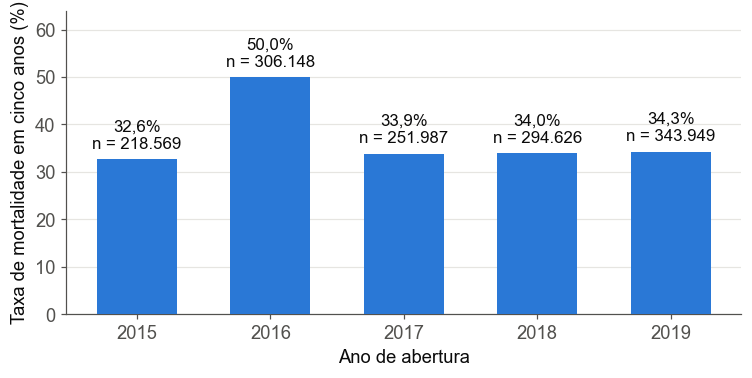

In [27]:
fig, ax = plt.subplots(figsize=(7.0, 3.6))
por_ano = Cc.groupby("ano_abertura").agg(empresas=("cnpj_basico", "size"),
                                          taxa=("y_mortalidade", "mean"))
barras = ax.bar(por_ano.index, por_ano["taxa"] * 100, color=AZUL, width=0.6, zorder=3)
ax.set_ylabel("Taxa de mortalidade em cinco anos (%)")
ax.set_xlabel("Ano de abertura")
ax.set_xticks(por_ano.index)
ax.set_ylim(0, por_ano["taxa"].max() * 128)
ax.yaxis.grid(True); ax.set_axisbelow(True)
for b, v, n in zip(barras, por_ano["taxa"] * 100, por_ano["empresas"]):
    ax.text(b.get_x() + b.get_width() / 2, v + ax.get_ylim()[1] * 0.025,
            f"{v:.1f}%".replace(".", ",") + f"\nn = {n:,.0f}".replace(",", "."),
            ha="center", va="bottom", fontsize=11)
fig.tight_layout()

salvar_figura(fig, 8, "Taxa de mortalidade em cinco anos das empresas mineiras por ano de abertura")
plt.show()


[salvo] fig09.png
--------------------------------------------------------------------------
Figura 9. Taxa de mortalidade em cinco anos por seção da Classificação Nacional de Atividades Econômicas
Nota: apenas seções com pelo menos mil empresas na coorte.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


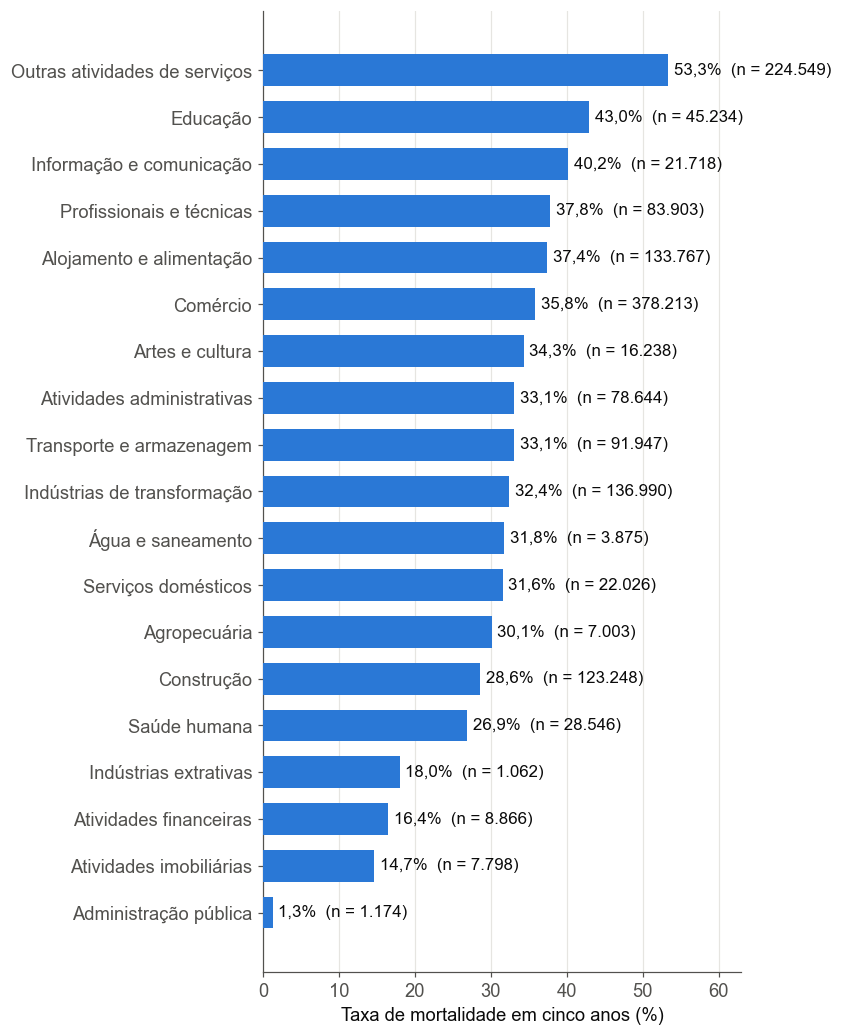


[salvo] tab07.csv
--------------------------------------------------------------------------
Tabela 7. Mortalidade empresarial por seção CNAE
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


WindowsPath('G:/Meu Drive/TCC/Damaris Rebeca/05_tabelas/tab07.csv')

In [28]:
NOMES_SECAO = {
    "A": "Agropecuária", "B": "Indústrias extrativas", "C": "Indústrias de transformação",
    "D": "Eletricidade e gás", "E": "Água e saneamento", "F": "Construção",
    "G": "Comércio", "H": "Transporte e armazenagem", "I": "Alojamento e alimentação",
    "J": "Informação e comunicação", "K": "Atividades financeiras", "L": "Atividades imobiliárias",
    "M": "Profissionais e técnicas", "N": "Atividades administrativas", "O": "Administração pública",
    "P": "Educação", "Q": "Saúde humana", "R": "Artes e cultura",
    "S": "Outras atividades de serviços", "T": "Serviços domésticos", "U": "Organismos internacionais",
}

por_secao = (Cc.groupby("cnae_secao")
               .agg(empresas=("cnpj_basico", "size"), taxa=("y_mortalidade", "mean")))
por_secao = por_secao[por_secao["empresas"] >= 1000].sort_values("taxa")
por_secao["rotulo"] = [NOMES_SECAO.get(i, i) for i in por_secao.index]

fig, ax = plt.subplots(figsize=(7.6, 0.42 * len(por_secao) + 1.6))
barras = ax.barh(por_secao["rotulo"], por_secao["taxa"] * 100, color=AZUL, height=0.68, zorder=3)
ax.set_xlabel("Taxa de mortalidade em cinco anos (%)")
ax.xaxis.grid(True); ax.set_axisbelow(True)
ax.set_xlim(0, por_secao["taxa"].max() * 118)
for b, v, n in zip(barras, por_secao["taxa"] * 100, por_secao["empresas"]):
    ax.text(v + ax.get_xlim()[1] * 0.012, b.get_y() + b.get_height() / 2,
            f"{v:.1f}%".replace(".", ",") + f"  (n = {n:,.0f})".replace(",", "."),
            va="center", fontsize=11)
fig.tight_layout()

salvar_figura(fig, 9, "Taxa de mortalidade em cinco anos por seção da Classificação Nacional de Atividades Econômicas",
              nota="Nota: apenas seções com pelo menos mil empresas na coorte.")
plt.show()

salvar_tabela(por_secao.reset_index()[["cnae_secao", "rotulo", "empresas", "taxa"]]
                .rename(columns={"cnae_secao": "Seção", "rotulo": "Descrição",
                                 "empresas": "Empresas", "taxa": "Taxa de mortalidade"}),
              7, "Mortalidade empresarial por seção CNAE")


[salvo] fig10.png
--------------------------------------------------------------------------
Figura 10. Curva de sobrevivência das empresas mineiras por enquadramento como microempreendedor individual
Nota: estimador de Kaplan-Meier; empresas ativas ao fim da janela entram como censuradas.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


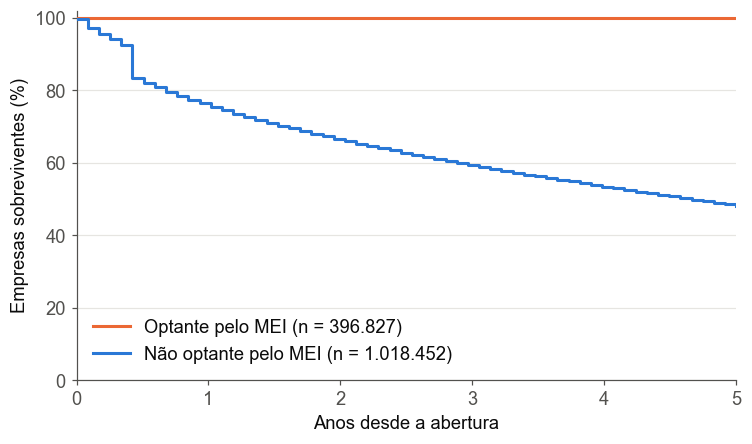

In [30]:
def kaplan_meier(tempos, eventos_obs, horizonte=5.0, passos=60):
    tempos = np.asarray(tempos, dtype=float)
    eventos_obs = np.asarray(eventos_obs, dtype=int)
    grade = np.linspace(0, horizonte, passos)
    n = len(tempos)
    sobrevivencia, s = [], 1.0
    ordenados = np.sort(np.unique(tempos[eventos_obs == 1]))
    idx = 0
    for t in grade:
        while idx < len(ordenados) and ordenados[idx] <= t:
            te = ordenados[idx]
            em_risco = (tempos >= te).sum()
            falhas = ((tempos == te) & (eventos_obs == 1)).sum()
            if em_risco > 0:
                s *= (1 - falhas / em_risco)
            idx += 1
        sobrevivencia.append(s)
    return grade, np.array(sobrevivencia)

fig, ax = plt.subplots(figsize=(7.0, 4.2))
grupos = [("Optante pelo MEI", Cc[Cc["optante_mei"] == 1], LARANJA),
          ("Não optante pelo MEI", Cc[Cc["optante_mei"] == 0], AZUL)]
for rotulo, sub, cor in grupos:
    if len(sub) < 100:
        continue
    g, s = kaplan_meier(sub["tempo_ate_evento_anos"], sub["evento_observado"])
    ax.step(g, s * 100, where="post", color=cor, linewidth=2, zorder=3,
            label=f"{rotulo} (n = {len(sub):,})".replace(",", "."))
ax.set_xlabel("Anos desde a abertura")
ax.set_ylabel("Empresas sobreviventes (%)")
ax.set_xlim(0, 5); ax.set_ylim(0, 102)
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(loc="lower left")
fig.tight_layout()

salvar_figura(fig, 10, "Curva de sobrevivência das empresas mineiras por enquadramento como microempreendedor individual",
              nota="Nota: estimador de Kaplan-Meier; empresas ativas ao fim da janela entram como censuradas.")
plt.show()

---
# 5. Camada B: caracterização do sistema financeiro

Entra no artigo como descrição, não como previsão. O motivo é empírico e vale escrito assim no texto: a relação de regimes especiais do Banco Central é um cadastro **corrente**, e não histórico. Traz 23 instituições ainda em liquidação, quase todas decretadas em 2025 e 2026, fora da janela do painel. Instituições cuja liquidação foi encerrada saem da relação.

In [32]:
B_val = B[B["ano"] <= 2024].copy() if B is not None else None
print(f"exercicios considerados: {int(B_val['ano'].min())} a {int(B_val['ano'].max())}")
print("2025 excluido porque so o relatorio de Informacoes de Capital foi publicado nesse exercicio")

perfil_b = pd.DataFrame([
    ["Observações instituição-exercício", f"{len(B_val):,}".replace(",", ".")],
    ["Instituições distintas", f"{B_val['cod_inst'].nunique():,}".replace(",", ".")],
    ["Período coberto", f"{int(B_val['ano'].min())} a {int(B_val['ano'].max())}"],
    ["Instituições com sede em Minas Gerais", f"{B_val[B_val['uf'] == 'MG']['cod_inst'].nunique():,}".replace(",", ".")],
    ["Índice de Basileia mediano", f"{B_val['basileia'].median():.1f}".replace(".", ",")],
    ["Retorno sobre o ativo mediano", f"{B_val['roa'].median():.2%}".replace(".", ",")],
    ["Instituições com prejuízo no período", f"{B_val['prejuizo'].mean():.1%}".replace(".", ",")],
], columns=["Característica", "Valor"])

salvar_tabela(perfil_b, 8, "Caracterização do painel de instituições financeiras")
print(perfil_b.to_string(index=False))

exercicios considerados: 2014 a 2024
2025 excluido porque so o relatorio de Informacoes de Capital foi publicado nesse exercicio

[salvo] tab08.csv
--------------------------------------------------------------------------
Tabela 8. Caracterização do painel de instituições financeiras
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                       Característica       Valor
    Observações instituição-exercício      15.211
               Instituições distintas       1.908
                      Período coberto 2014 a 2024
Instituições com sede em Minas Gerais         251
           Índice de Basileia mediano        27,3
        Retorno sobre o ativo mediano       1,50%
 Instituições com prejuízo no período       16,0%



[salvo] fig11.png
--------------------------------------------------------------------------
Figura 11. Evolução da solvência e da rentabilidade medianas das instituições financeiras
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


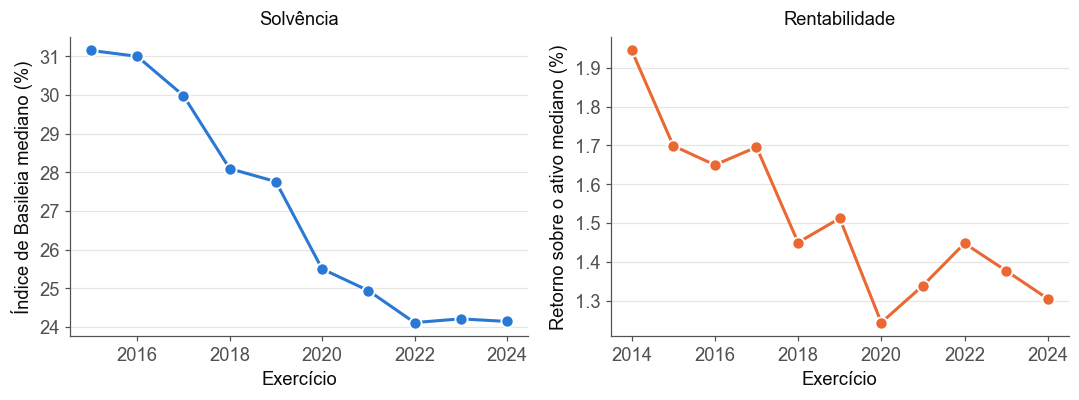

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.8))

serie_bas = B_val.groupby("ano")["basileia"].median().dropna()
axes[0].plot(serie_bas.index, serie_bas.values, color=AZUL, linewidth=2,
             marker="o", markersize=8, markeredgecolor="white", markeredgewidth=1.2, zorder=3)
axes[0].set_ylabel("Índice de Basileia mediano (%)")
axes[0].set_xlabel("Exercício")
axes[0].yaxis.grid(True); axes[0].set_axisbelow(True)
axes[0].set_title("Solvência", pad=8)

serie_roa = B_val.groupby("ano")["roa"].median().dropna() * 100
axes[1].plot(serie_roa.index, serie_roa.values, color=LARANJA, linewidth=2,
             marker="o", markersize=8, markeredgecolor="white", markeredgewidth=1.2, zorder=3)
axes[1].set_ylabel("Retorno sobre o ativo mediano (%)")
axes[1].set_xlabel("Exercício")
axes[1].yaxis.grid(True); axes[1].set_axisbelow(True)
axes[1].set_title("Rentabilidade", pad=8)

fig.tight_layout()
salvar_figura(fig, 11, "Evolução da solvência e da rentabilidade medianas das instituições financeiras")
plt.show()


[salvo] fig12.png
--------------------------------------------------------------------------
Figura 12. Distribuição das instituições financeiras por unidade da federação da sede, dez maiores
Nota: Minas Gerais destacado em laranja.
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------


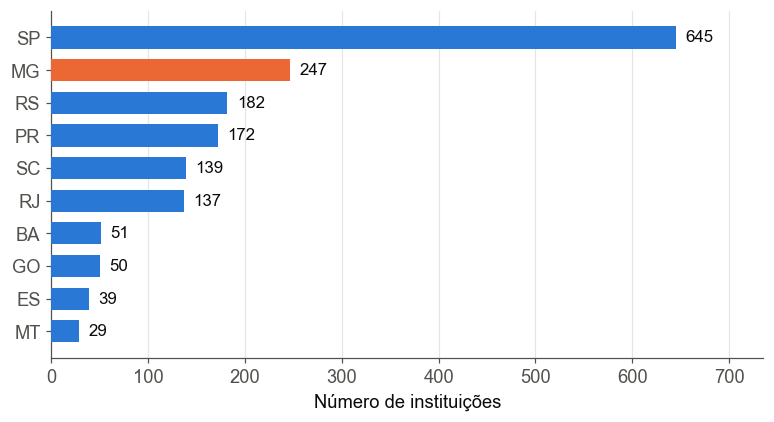

In [34]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))
por_uf_b = (B_val.drop_duplicates(subset=["cod_inst"])["uf"].replace("", "Não informada")
                 .value_counts().head(10).sort_values())
cores = [LARANJA if uf == "MG" else AZUL for uf in por_uf_b.index]
barras = ax.barh(por_uf_b.index, por_uf_b.values, color=cores, height=0.68, zorder=3)
ax.set_xlabel("Número de instituições")
ax.xaxis.grid(True); ax.set_axisbelow(True)
ax.set_xlim(0, por_uf_b.max() * 1.14)
for b, v in zip(barras, por_uf_b.values):
    ax.text(v + por_uf_b.max() * 0.015, b.get_y() + b.get_height() / 2,
            f"{v:,}".replace(",", "."), va="center", fontsize=11)
fig.tight_layout()

salvar_figura(fig, 12, "Distribuição das instituições financeiras por unidade da federação da sede, dez maiores",
              nota="Nota: Minas Gerais destacado em laranja.")
plt.show()

In [35]:
mg = B_val[B_val["uf"] == "MG"]
brasil = B_val

comparativo_mg = pd.DataFrame({
    "Minas Gerais": [
        mg["cod_inst"].nunique(),
        f"{mg['basileia'].median():.1f}".replace(".", ","),
        f"{mg['roa'].median():.2%}".replace(".", ","),
        f"{mg['pl_sobre_ativo'].median():.2%}".replace(".", ","),
        f"{mg['credito_sobre_ativo'].median():.2%}".replace(".", ","),
        f"{mg['prejuizo'].mean():.1%}".replace(".", ","),
    ],
    "Brasil": [
        brasil["cod_inst"].nunique(),
        f"{brasil['basileia'].median():.1f}".replace(".", ","),
        f"{brasil['roa'].median():.2%}".replace(".", ","),
        f"{brasil['pl_sobre_ativo'].median():.2%}".replace(".", ","),
        f"{brasil['credito_sobre_ativo'].median():.2%}".replace(".", ","),
        f"{brasil['prejuizo'].mean():.1%}".replace(".", ","),
    ],
}, index=["Instituições", "Índice de Basileia mediano", "Retorno sobre o ativo mediano",
          "Patrimônio líquido sobre ativo mediano", "Carteira de crédito sobre ativo mediana",
          "Observações com prejuízo"])
comparativo_mg.index.name = "Indicador"

salvar_tabela(comparativo_mg, 9, "Sistema financeiro mineiro em comparação com o conjunto do país", indice=True)
print(comparativo_mg.to_string())


[salvo] tab09.csv
--------------------------------------------------------------------------
Tabela 9. Sistema financeiro mineiro em comparação com o conjunto do país
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                                        Minas Gerais  Brasil
Indicador                                                   
Instituições                                     251    1908
Índice de Basileia mediano                      30,1    27,3
Retorno sobre o ativo mediano                  1,70%   1,50%
Patrimônio líquido sobre ativo mediano        20,49%  22,54%
Carteira de crédito sobre ativo mediana       55,34%  55,36%
Observações com prejuízo                        8,4%   16,0%


---
# 6. Quadro comparativo e exportação

In [37]:
quadro = pd.DataFrame([
    {"Camada": "A. Companhias abertas",
     "Fonte": "CVM, demonstrações financeiras padronizadas",
     "Unidade": "Companhia e exercício",
     "Observações": f"{len(A_elegivel):,}".replace(",", "."),
     "Unidades distintas": f"{A['CNPJ_CIA'].nunique():,}".replace(",", "."),
     "Período": f"{int(A['ANO'].min())} a {int(A['ANO'].max())}",
     "Desfecho": "Recuperação judicial ou falência",
     "Eventos": f"{int(A_elegivel['y_rj'].sum())}",
     "Taxa": f"{A_elegivel['y_rj'].mean():.2%}".replace(".", ","),
     "Papel no artigo": "Estudo preditivo principal"},
    {"Camada": "B. Instituições financeiras",
     "Fonte": "BACEN, IF.data",
     "Unidade": "Instituição e exercício",
     "Observações": f"{len(B_val):,}".replace(",", "."),
     "Unidades distintas": f"{B_val['cod_inst'].nunique():,}".replace(",", "."),
     "Período": f"{int(B_val['ano'].min())} a {int(B_val['ano'].max())}",
     "Desfecho": "Liquidação extrajudicial",
     "Eventos": "0 na janela",
     "Taxa": "não aplicável",
     "Papel no artigo": "Caracterização descritiva"},
    {"Camada": "C. Coorte mineira",
     "Fonte": "Receita Federal, dados públicos de CNPJ",
     "Unidade": "Empresa",
     "Observações": f"{len(Cc):,}".replace(",", "."),
     "Unidades distintas": f"{Cc['cnpj_basico'].nunique():,}".replace(",", "."),
     "Período": f"{int(Cc['ano_abertura'].min())} a {int(Cc['ano_abertura'].max())}",
     "Desfecho": "Mortalidade empresarial em cinco anos",
     "Eventos": f"{int(Cc['y_mortalidade'].sum()):,}".replace(",", "."),
     "Taxa": f"{Cc['y_mortalidade'].mean():.2%}".replace(".", ","),
     "Papel no artigo": "Estudo preditivo complementar"},
])

salvar_tabela(quadro, 10, "Quadro comparativo das três camadas de dados")
print(quadro.to_string(index=False))


[salvo] tab10.csv
--------------------------------------------------------------------------
Tabela 10. Quadro comparativo das três camadas de dados
Fonte: Resultados originais da pesquisa
--------------------------------------------------------------------------
                     Camada                                       Fonte                 Unidade Observações Unidades distintas     Período                              Desfecho     Eventos          Taxa               Papel no artigo
      A. Companhias abertas CVM, demonstrações financeiras padronizadas   Companhia e exercício       8.453                980 2011 a 2025      Recuperação judicial ou falência          48         0,57%    Estudo preditivo principal
B. Instituições financeiras                              BACEN, IF.data Instituição e exercício      15.211              1.908 2014 a 2024              Liquidação extrajudicial 0 na janela não aplicável     Caracterização descritiva
          C. Coorte mineira     Rece

In [38]:
caminho_xlsx = DIR_TAB / "tabelas_do_artigo.xlsx"
with pd.ExcelWriter(caminho_xlsx, engine="openpyxl") as escritor:
    for t in TABELAS:
        aba = f"Tabela {t['numero']}"
        t["dados"].to_excel(escritor, sheet_name=aba[:31],
                            index=t["dados"].index.name is not None)

indice = pd.DataFrame(
    [{"Tipo": "Figura", "Número": f["numero"], "Arquivo": f["arquivo"], "Título": f["titulo"]} for f in FIGURAS]
    + [{"Tipo": "Tabela", "Número": t["numero"], "Arquivo": t["arquivo"], "Título": t["titulo"]} for t in TABELAS]
).sort_values(["Tipo", "Número"])
indice.to_csv(DIR_TAB / "indice_figuras_tabelas.csv", index=False, encoding="utf-8-sig", sep=";")

print(f"{len(FIGURAS)} figuras em {DIR_FIG}")
print(f"{len(TABELAS)} tabelas em {DIR_TAB}")
print(f"planilha consolidada: {caminho_xlsx.name}\n")
print(indice.to_string(index=False, max_colwidth=68))

12 figuras em G:\Meu Drive\TCC\Damaris Rebeca\05_figuras
10 tabelas em G:\Meu Drive\TCC\Damaris Rebeca\05_tabelas
planilha consolidada: tabelas_do_artigo.xlsx

  Tipo  Número   Arquivo                                                               Título
Figura       1 fig01.png Distribuição anual dos eventos de recuperação judicial e falência...
Figura       2 fig02.png Distribuição das companhias abertas por unidade da federação da s...
Figura       3 fig03.png Distribuição dos seis indicadores de maior poder discriminante en...
Figura       4 fig04.png Trajetória mediana dos indicadores nos exercícios que antecedem a...
Figura       5 fig05.png    Matriz de correlação de Spearman entre os indicadores financeiros
Figura       6 fig06.png Curva ROC dos escores clássicos na previsão de recuperação judici...
Figura       7 fig07.png Taxa de insolvência observada por faixa de classificação do Termô...
Figura       8 fig08.png Taxa de mortalidade em cinco anos das empresas mineiras por ano

In [39]:
print("LISTA DE LEGENDAS PARA COLAR NO ARTIGO\n")
print("=" * 74)
for f in FIGURAS:
    print(f"\nFigura {f['numero']}. {f['titulo']}")
    print("Fonte: Resultados originais da pesquisa")
print("\n" + "=" * 74)
for t in TABELAS:
    print(f"\nTabela {t['numero']}. {t['titulo']}")
    print("Fonte: Resultados originais da pesquisa")

LISTA DE LEGENDAS PARA COLAR NO ARTIGO


Figura 1. Distribuição anual dos eventos de recuperação judicial e falência entre companhias abertas, 2012 a 2026
Fonte: Resultados originais da pesquisa

Figura 2. Distribuição das companhias abertas por unidade da federação da sede, dez maiores
Fonte: Resultados originais da pesquisa

Figura 3. Distribuição dos seis indicadores de maior poder discriminante entre companhias saudáveis e insolventes
Fonte: Resultados originais da pesquisa

Figura 4. Trajetória mediana dos indicadores nos exercícios que antecedem a insolvência
Fonte: Resultados originais da pesquisa

Figura 5. Matriz de correlação de Spearman entre os indicadores financeiros
Fonte: Resultados originais da pesquisa

Figura 6. Curva ROC dos escores clássicos na previsão de recuperação judicial e falência
Fonte: Resultados originais da pesquisa

Figura 7. Taxa de insolvência observada por faixa de classificação do Termômetro de Kanitz
Fonte: Resultados originais da pesquisa

Figura 8

---
## Como usar isto no artigo

As figuras estão em `05_figuras` a 300 dpi, com Arial 12, prontas para inserir no Word sem redimensionar. As tabelas estão em `05_tabelas`, tanto em CSV separado por ponto e vírgula com vírgula decimal, que abre direto no Excel em português, quanto consolidadas na planilha `tabelas_do_artigo.xlsx`, uma aba por tabela.

A última célula imprime todas as legendas no padrão do artigo. É copiar e colar.

## Sugestão de encadeamento da seção de resultados

Comece pela caracterização das amostras, com a Tabela 1 e a Figura 1, que situam o leitor no que está sendo estudado e mostram que os eventos se distribuem ao longo de toda a janela, e não concentrados num choque específico.

Passe à comparação entre grupos, com a Tabela 3 e a Figura 3. É aqui que se estabelece que os indicadores de fato discriminam, com teste estatístico e tamanho de efeito, antes de qualquer modelo.

A Figura 4 é a que rende mais discussão, porque mostra com quanta antecedência o sinal contábil aparece. Se a deterioração já for visível em três exercícios antes, isso justifica sozinho a escolha do horizonte de previsão.

A Figura 6 e a Tabela 4 fecham a linha de base. O AUC dos escores clássicos é o número contra o qual o desempenho do machine learning vai ser comparado na entrega seguinte, e é o que transforma o trabalho de aplicação em contribuição.

A camada mineira entra depois, com a Tabela 6 e as Figuras 8 a 10, e a caracterização do sistema financeiro fecha como contraponto.